In [ ]:
#由Two_Envelopes_Paradox问题期望reward悖论
#--numpy/jax numpy simulation对比--jax好处
#--双x/2x变量结果影响最终分布--CLT 在drl中应用 常见

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
#JAX 版本的 NumPy，API 几乎和 numpy 完全一致，但是所有运算都支持 GPU 加速、可并行批处理。
from scipy.stats import norm
#Scipy 科学计算库的统计模块，这里导入正态分布工具
# Set plot styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
# 需要大批量随机生成组合优化可行解（背包、最大独立集等）时，
# JAX 可以一次性并行生成几万、几十万组随机解，速度远快于普通 NumPy，完美适配大规模采样实验。
#1.写法接近 NumPy 2.可以被 JIT 编译加速
#3.可以在 GPU/TPU 上跑 4.很适合批量计算
#5.和自动求导天然结合

#####%%%%%%JAX = 像 NumPy 一样写数组计算，但更适合大规模并行、GPU/TPU 加速、自动求导和强化学习。        !!!!!
# NumPy 主要在 CPU 上跑，不太适合 Deep RL 那种“大规模并行 + 自动求导 + 编译优化”的场景

In [2]:
# np.mean(...)/jnp.mean(...)

# np.where(...)/jnp.where(...)

# np.reshape(...)/jnp.reshape(...)

In [3]:
# %%[PART1:Numpy Simulation]

#X ~ Uniform(1, 100),base_amounts
# Envelope_A = X
# Envelope_B = 2X

# E[Envelope_A] = (1 + 100) / 2 = 50.5
# E[Envelope_B] = 101

# E[Keep] = 0.5 * E[Envelope_A] + 0.5 * E[Envelope_B]
#         = 0.5 * 50.5 + 0.5 * 101
#         = 75.75

# E[Keep] ≈ E[Swap] ≈ 75.75

In [4]:
def simulate_two_envelopes_numpy(num_trials=100000):
    base_amounts = np.random.uniform(1, 100, size=num_trials)
    #np.random.randint(low, high, size)
    # 作用：生成一组随机整数数组
    
    env_A = base_amounts
    env_B = 2 * base_amounts
    choices = np.random.randint(0, 2, size=num_trials)

    #np.where(条件, 条件成立时取值, 条件不成立时取值)
    keep_rewards = np.where(choices == 0, env_A, env_B)
    swap_rewards = np.where(choices == 0, env_B, env_A)

    return keep_rewards, swap_rewards

# Run the simulation 把函数返回的两组结果分别赋值给两个变量
keep_res, swap_res = simulate_two_envelopes_numpy(100000)

print(f"Expected Return (Keep): ${np.mean(keep_res):.2f}")
print(f"Expected Return (Swap): ${np.mean(swap_res):.2f}")
print(f"Difference: ${np.mean(swap_res) - np.mean(keep_res):.5f}")

Expected Return (Keep): $75.80
Expected Return (Swap): $75.88
Difference: $0.07994


In [5]:
# %% [markdown]
# ### Reflection
# *Does the simulation agree with the $1.25A$ paradox? Should we change?*
# **Answer:** No. The empirical expected values are identical (approximately $75). 
#The paradox vanishes when a proper probability distribution generates the base amounts. 
#If you observe $A = 150$, the other envelope *must* be $75$, it cannot be $300$ because our base $X$ maxes out at $100$.

In [6]:
# ## Part 2: Parallel Simulation with JAX
#
# In Deep Reinforcement Learning, we cannot rely on Python `for` loops 
# or even standard `numpy` if we want to run millions of environments on a GPU. We use **JAX**.

In [7]:
# ### Question 2: Vectorizing with JAX
# Rewrite your simulation using `jax.numpy` and `jax.random`. We will simulate $10,000,000$ games. 
#Notice how we must explicitly pass the pseudo-random number generator (PRNG) `key`.
#####%%%%%注意我们必须如何明确地传递伪随机数生成器（PRNG）“密钥”                                   !!!!!

    # key = jax.random.PRNGKey(42)
    # jax.random.split(key)
    # jax.random.uniform(...)
    # jax.random.bernoulli(...)
    # jax.jit(...)

In [8]:
##%%[key in jax!!!]===seed:)
#这个 key 可以理解成：随机数种子 + 随机数状态
#42: seed。相同的 seed 会生成相同的随机数，方便复现实验。

##np.random.uniform(1, 100, size=5)

##key = jax.random.PRNGKey(42)
#jax.random.uniform(key, shape=(5,), minval=1.0, maxval=100.0)

In [9]:
##numpy-内部会自己维护随机状态
#base_amounts = np.random.uniform(...)
#choices = np.random.randint(...)

##jax:每一次独立随机操作，最好使用一个新的 key===split(key)

In [10]:
def simulate_two_envelopes_jax(key, num_trials):
    key_x, key_choice = jax.random.split(key)
    
    base_amounts = jax.random.uniform(key_x, shape=(num_trials,), minval=1.0, maxval=100.0)
    
    env_A = base_amounts
    env_B = 2 * base_amounts
    choices = jax.random.bernoulli(key_choice, p=0.5, shape=(num_trials,))
    #False 表示选 env_A/True 表示选 env_B

    #same//jnp.where(条件, 条件成立时取值, 条件不成立时取值)
    keep_rewards = jnp.where(choices, env_B, env_A)
    swap_rewards = jnp.where(choices, env_A, env_B)

    return keep_rewards, swap_rewards

In [11]:
#numpy到这就输出了
#普通 Python 函数是一行一行解释执行。
###%%%JIT 之后，JAX 会尽量把整段数组计算优化成高效执行。

# Compile the function using JIT (Just-In-Time) compilation for maximum speed
#JAX 先看一遍这个函数，知道你要做什么数组运算，然后把它编译成更高效的底层计算图。
##先把这个函数翻译成更底层、更快的计算版本，再执行
jit_simulate = jax.jit(simulate_two_envelopes_jax, static_argnums=(1,))

# Run 10 million environments
key = jax.random.PRNGKey(42)
N_ENVS = 10_000_000

# Execute (the first run compiles it, subsequent runs are lightning fast)
jax_keep, jax_swap = jit_simulate(key, N_ENVS)

print(f"JAX Expected Return (Keep): ${jnp.mean(jax_keep):.4f}")
print(f"JAX Expected Return (Swap): ${jnp.mean(jax_swap):.4f}")

JAX Expected Return (Keep): $75.7360
JAX Expected Return (Swap): $75.7523


In [12]:
##numpy

## Run the simulation 把函数返回的两组结果分别赋值给两个变量
# keep_res, swap_res = simulate_two_envelopes_numpy(100000)

# print(f"Expected Return (Keep): ${np.mean(keep_res):.2f}")
# print(f"Expected Return (Swap): ${np.mean(swap_res):.2f}")
# print(f"Difference: ${np.mean(swap_res) - np.mean(keep_res):.5f}")

In [13]:
# ## Part 3: Numerically Demonstrating the Central Limit Theorem
#
# The **Central Limit Theorem (CLT)** 很好理解 样本量足够大 那无论这个概率weight怎样 
# 满足X_i: independent identically distribution 最终则应normal

#states that the distribution of the *sample mean* of independent, 
#identically distributed (i.i.d.) random variables approaches a Gaussian (Normal) distribution 
#as the sample size $N$ gets large, regardless of the underlying distribution's shape!

In [14]:
# The true distribution of our envelope rewards is weird
#(it's a mixture of two uniform distributions, $X$ and $2X$). It is **not** a bell curve.
#
# ### Question 3: The Sample Mean Distribution
# Let's group our $10,000,000$ JAX results into $M = 10,000$ batches, each of size $N = 1,000$.
# 1. Calculate the mean of each batch.
# 2. Plot the histogram of these $10,000$ sample means.
# 3. Overlay the theoretical Normal distribution predicted by the CLT.

In [15]:
M = 10000
N = 1000
batches = jnp.reshape(jax_keep, (M, N))
#(10000, 1000)

sample_means = jnp.mean(batches, axis=1) #按行 单M内求平均

population_mean = jnp.mean(jax_keep)
population_std = jnp.std(jax_keep)
#the standard deviation of the sample mean (Standard Error)
theoretical_se = population_std / jnp.sqrt(N)

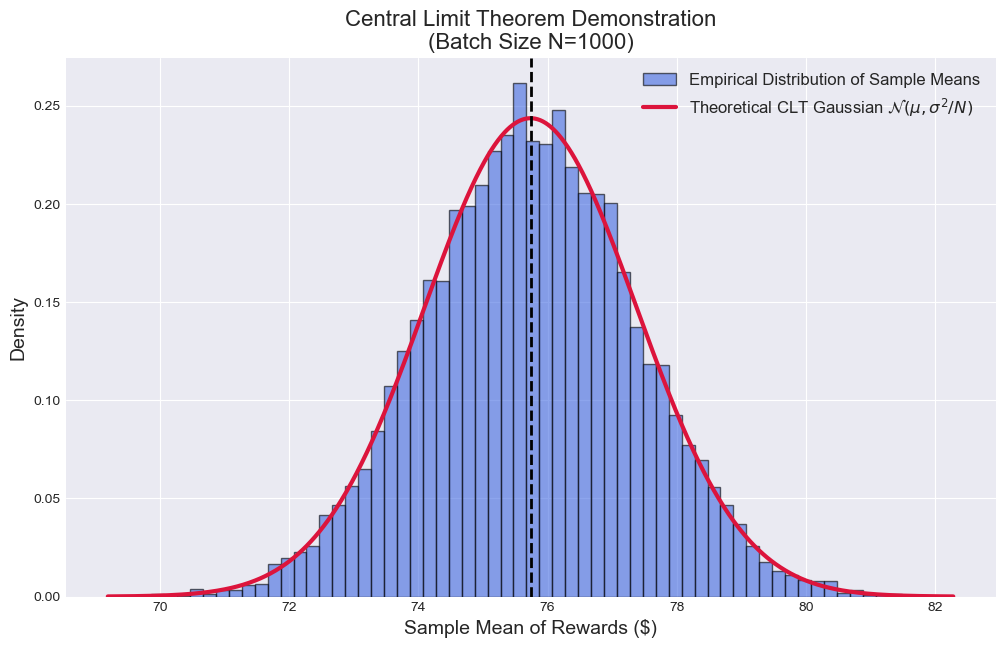

In [16]:
# 4. Plotting
plt.figure(figsize=(12, 7))

#density=True：将直方图转为概率密度，可以和理论正态 PDF 曲线对齐对比
plt.hist(np.array(sample_means), bins=60, density=True, alpha=0.6,
         color='royalblue', edgecolor='black', label='Empirical Distribution of Sample Means')

x_axis = np.linspace(float(population_mean - 4*theoretical_se), float(population_mean + 4*theoretical_se), 1000)
y_axis = norm.pdf(x_axis, float(population_mean), float(theoretical_se))

plt.plot(x_axis, y_axis, color='crimson', lw=3, label=r'Theoretical CLT Gaussian $\mathcal{N}(\mu, \sigma^2/N)$')

plt.title(f'Central Limit Theorem Demonstration\n(Batch Size N={N})', fontsize=16)
plt.xlabel('Sample Mean of Rewards ($)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.axvline(float(population_mean), color='black', linestyle='dashed', lw=2, label='True Population Mean')
plt.show()


In [17]:
#在深度强化学习（DQN、PPO 等算法）中，CLT 是非常核心的理论支撑：
#我们不会用全部千万条样本计算梯度，而是拆分成多个小批量（mini-batch）
#每个小批量计算一次梯度，用批量梯度均值作为真实梯度方向的估计
#依靠中心极限定理：小批量梯度的抽样分布服从正态分布，我们的梯度估计是稳定、可靠的，不会因为单次采样偏差导致训练崩溃
#这也是强化学习可以用小批量随机梯度下降稳定训练的底层数学原理。